# Training `GPTModel`

In [2]:
import torch
import torch.nn as nn

# Import already prepared `GPTModel` abstraction
import sys 
sys.path.append("../..")

from gpt_module import GPTModel

In [3]:
import tiktoken

torch.manual_seed(123)
context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
tokenized_context = tokenizer.encode(context)
input_sequence = torch.tensor(tokenized_context).unsqueeze(0)

GPT_CONFIG = {
    "vocab_size": 50257,          # Vocabulary size, the number of unique tokens available to be generated.
    "context_window_size": 256,   # Context window size, the maximum number of tokens model can see, learn and effectively predict on.
    "emb_dim": 768,               # Embedding dimension to capture meaning in a vector space.
    "n_heads": 12,                # Number of attention heads.
    "n_layers": 12,               # Number of transformer block layers. 
    "drop_rate": 0.1,             # Dropout rate to avoid overfitting.
    "qkv_bias": False             # Weather Query-Key-Value matrices includes bias along with weights.
}

model = GPTModel(cfg=GPT_CONFIG)
model.eval(); # enable inference mode unlike gpt_model.train() for enabling training mode.

In [4]:
import tiktoken

def text_generation_app(model, input_text, max_new_tokens, context_window_size):
    
    for i in range(max_new_tokens):
        # Truncate input_text to the size limit of the context window.
        limited_context_window = input_text[:, -context_window_size:]

        # Disable computation graph of back propgation in background
        with torch.no_grad():
            logits = model(limited_context_window)

        # Extract the last index value
        logits = logits[:, -1, :]

        # Normalize for easier interpretation of logits scores as probabilities; it is optional as high scores in logits always leads to high probablities.
        probabilities = torch.softmax(logits, dim=-1)

        # Extract the index of the max value in probabilities as index represent the most likelable next_token_id which should come after the last token in the input_text.
        next_token_id = torch.argmax(probabilities, dim=-1, keepdim=True)

        # Concatenate next_token_id to the input_text.
        input_text = torch.cat((input_text, next_token_id), dim=1)

    # At the end of the loop (reaching limit of max tokens) autoregressiveness of input_text is the output_text.
    output_text = input_text
    
    return output_text


# Helper function to convert python list to tensors after invoking tokenizer to encode text into token_ids.
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

# Helper function to convert tensors back to python list and invoke tokenizer decode token_ids to text.
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [5]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = text_generation_app(
    model=model,
    input_text=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_window_size=GPT_CONFIG["context_window_size"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


## Quantifying text generation quality; Cross Entropy & Perplexity

- Loss function: Cross Entropy Loss.
- Perplexity is for the better interpretability.

In [6]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]

with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print(f"Probability Matrix Shape: {probas.shape}")

token_ids = torch.argmax(probas, dim=-1, keepdim=True)
token_ids

Probability Matrix Shape: torch.Size([2, 3, 50257])


tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])

In [7]:
print(f"Expected Targets: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Predicted Ouput: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Expected Targets:  effort moves you
Predicted Ouput:  Armed heNetflix


## From the predicted probability values matrix, Extract the probability values of target tokens IDs.

Goal: 
- First to know the currently predicted probabilities from model's output at locations of target tokens.
- Then maximize the values of these probabilities.
- `probas` has the shape of torch.Size([2, 3, 50257]), means two examples, each have 3 tokens, and each token has 50257 probability values at corresponding index being the next token.
- `probas[0][1][123] extract probability value associated to token id 123 as the chance of being the next token of second token in example 1.
- `probas[0][0,1,2][123] extract probability value associated to token id of 1 example targets `targets[0]` as the chance of being the next token of all tokens position in example 1.


Simple Words:
- The `probas` contains probability associated to all tokens at the index probas.
- Idea is to extract the probability value associated to target tokenIDs.
- Then maximize targets probability value during training and loss is the quantitative measure of learning quality.


In [7]:
# target probability values for 1st example.
target_probabs_1 = probas[0, [0,1,2], targets[0]]

# target probability values for 2nd example.
target_probabs_2 = probas[1, [0,1,2], targets[1]]

Concatenate the `target_probabs_1` and `target_probabs_2` for ease of calculations.

In [8]:
torch.cat((target_probabs_1, target_probabs_2))

tensor([7.4541e-05, 3.1061e-05, 1.1563e-05, 1.0337e-05, 5.6776e-05, 4.7559e-06])

## Calculate mean of log of `probabs`

Why?

The probability of right tokens being genearated at 0, 1, 2 token positions individually is represented in `probabs`

The total probability of all the generated tokens in the right order collectively is represented by multiplying all the values in probabs for each position.

Now,

The logarithms function turns multiplication into simple addition due to the mathematical identity: `log(A x B) = log(A) + log(B)`.

Total Probability=0.5×0.4×0.1=0.02

multiplying very small values together will lead to one very small value which is known as underflow problem in computers so we convert them to log so that we have ease of representing the values and gaining the same information.



In [9]:
log_probabs = torch.log(torch.cat((target_probabs_1, target_probabs_2)))
log_probabs

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])

**Note:** Smaller the value probab value, the higher the negative value.

In [10]:
mean_log_probabs = torch.mean(log_probabs)

print(f"mean_log_probabs: {mean_log_probabs}")
print(f"Positive of mean_log_probabs: {mean_log_probabs*-1}")

mean_log_probabs: -10.793963432312012
Positive of mean_log_probabs: 10.793963432312012


**Note:** Mean value to average out the effetc of sequence length. If we were not to use mean then training is dependent on example sizes and inference would be affected.

This positivized value of `mean_log_probabs` is called `cross_entropy_loss`.

During training, our goal is to make `mean_log_probabs` close to zero 
and in order to do that `log_probabs` needs to be close to zero
and in order to do that `target_probabs` needs to be larger.

## Abstraction of Loss Function by Cross Entropy Loss

In [95]:
import torch.nn as nn

## Originally `logit` is of `shape:[2, 3, 50257]`, we must flatten the first two dimensions to make it `[6, 50257]` 
logits_flat = logits.flatten(0, 1)

## Originally `targets` is of `shape:[2, 3]`, we must flatten the first two dimensions to make it `[6]` 
targets_flat = targets.flatten(0, 1)

# Pytorch provides a built-in abstraction `cross_entropy_loss`
nn.functional.cross_entropy(logits_flat, targets_flat)

# logits_flat
# targets_flat

tensor(10.7940)

**Note:** This value and positivized value of `mean_log_probabs` we calculated manually is the same.

## Divide the Input Corpus into Training and Validation Datasets

It is a typical machine learning startegy to split the data and set a side a portion of data for just validation (overfit or underfit) of trained model.

Rest of the data (major portion) will be used for training.

## Pipeline
- Load the corpus.
- Tokenize the corpus as list of token ids.
- Split the corpus into training & validation portions using a configured ratio.
- This token ids list is structured into batches of examples where each example is having number of tokens equal to `context_window_size`.
- Batches contains examples stacked onto of each other and these examples are not sequentially selected within a batch from corpus.

In [96]:
with open("data/corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

print(f"Characters in the corpus: {len(corpus)}")
print(f"Tokens in the corpus: {len(tokenizer.encode(corpus))}")

Characters in the corpus: 20479
Tokens in the corpus: 5145


In [97]:
# Import already prepared `GPTModel` abstraction
import sys 
sys.path.append("../..")

from data_loader_module import create_dataloader_v1

train_ratio = 0.90
split_idx = int(train_ratio * len(corpus))
train_data = corpus[:split_idx]
val_data = corpus[split_idx:]

In [14]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    tokenizer,
    batch_size=2,
    context_window_size=GPT_CONFIG["context_window_size"],
    stride=GPT_CONFIG["context_window_size"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    tokenizer,
    batch_size=2,
    context_window_size=GPT_CONFIG["context_window_size"],
    stride=GPT_CONFIG["context_window_size"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [15]:
# Verify the data loaders shape
for x,y in train_loader:
    print(f"Inputs(X): {x.shape} --> Targets(y): {y.shape}")

Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])
Inputs(X): torch.Size([2, 256]) --> Targets(y): torch.Size([2, 256])


In [16]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

In [17]:
def calc_loss_batch(input_batch, target_batch, model, device):
    # Transfer the input and target data batches to the configured GPU device.
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)      
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [18]:

# Check the GPU device support.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transfer the model to the same device where the data will be available.
model.to(device);

In [19]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758347829183
Validation loss: 10.981106758117676


**Note:** Practically we should strive to bring the loss value under 1.0.

# Training

In [20]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = text_generation_app(
            model=model, input_text=encoded,
            max_new_tokens=50, context_window_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [21]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG)
model.to(device)

optimizer = torch.optim.AdamW(
     model.parameters(),
    lr=0.0004, weight_decay=0.1
)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

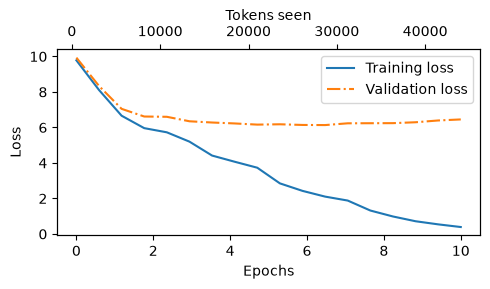

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Decoding strategies to control randomness

### Temperature Scaling

In [1]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(f"Maximum probability always: {inverse_vocab[next_token_id]}")

next_token_id = torch.multinomial(probas, num_samples=1).item()
print(f"Distribution based probability: {inverse_vocab[next_token_id]}")

NameError: name 'torch' is not defined

In [24]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

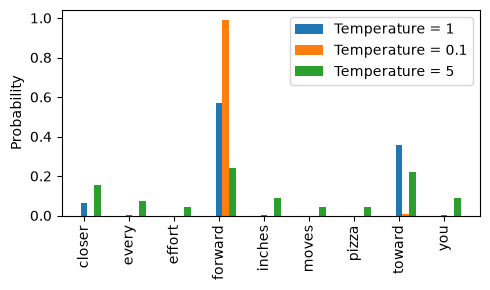

In [25]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
                for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], 
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### Top-k Sampling

In [26]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [27]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [28]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Sophisticated Text Generation App

In [29]:
def generate_app(model, input_text, max_new_tokens, context_window_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = input_text[:, -context_window_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
            break
        input_text = torch.cat((input_text, idx_next), dim=1)
    return input_text

In [30]:
torch.manual_seed(123)
token_ids = generate_app(
    model=model,
    input_text=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_window_size=GPT_CONFIG["context_window_size"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youlit terrace.



" he said deprecating laugh


## Loading and saving model weights in PyTorch

In [31]:
torch.save(model.state_dict(), "model.pth")

In [32]:
model = GPTModel(GPT_CONFIG)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval();

In [33]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

In [34]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## Loading pretrained weights from OpenAI

In [38]:
pip install tensorflow>=2.15.0  tqdm>=4.66

zsh:1: 2.15.0 not found
Note: you may need to restart the kernel to use updated packages.


In [41]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x137d09ed0>)

In [43]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json


model.ckpt.data-00000-of-00001: 100%|██████████████████████████████████████████████| 498M/498M [06:53<00:00, 1.20MiB/s]


File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [89]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,          # Vocabulary size, the number of unique tokens available to be generated.
    "context_window_size": 1024,  # Context window size, the maximum number of tokens model can see, learn and effectively predict on.
    "emb_dim": 768,               # Embedding dimension to capture meaning in a vector space.
    "n_heads": 12,                # Number of attention heads.
    "n_layers": 12,               # Number of transformer block layers. 
    "drop_rate": 0.1,             # Dropout rate to avoid overfitting.
    "qkv_bias": False             # Weather Query-Key-Value matrices includes bias along with weights.
}


model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

# print(params["blocks"][0]["attn"]);

In [80]:
import numpy as np

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )

    # `torch.nn.Parameter` has two properties `weight` & `bias`.
    return torch.nn.Parameter(torch.tensor(right))

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for trf_block in range(len(params["blocks"])):

        # Splitting one giant matrix into three smaller attention's weight matrices q_w, k_w, v_w.
        q_w, k_w, v_w = np.split((params["blocks"][trf_block]["attn"]["c_attn"])["w"], 3, axis=-1)

        # Splitting one giant matrix into three smaller attention's biases matrices q_b, k_b, v_b.
        q_b, k_b, v_b = np.split((params["blocks"][trf_block]["attn"]["c_attn"])["b"], 3, axis=-1)

        # Loading values of `W_query`, `W_key`, `W_value` in each transformer block's attention mechanism's `nn.Embedding` layer's weight parameter.
        gpt.trf_blocks[trf_block].att.W_query.weight = assign(gpt.trf_blocks[trf_block].att.W_query.weight, q_w.T)
        gpt.trf_blocks[trf_block].att.W_key.weight = assign(gpt.trf_blocks[trf_block].att.W_key.weight, k_w.T)
        gpt.trf_blocks[trf_block].att.W_value.weight = assign(gpt.trf_blocks[trf_block].att.W_value.weight, v_w.T)

        # Loading values of `W_bias`, `W_bias`, `W_bias` in each transformer block's attention mechanism's `nn.Embedding` layer's weight parameter.
        gpt.trf_blocks[trf_block].att.W_query.bias = assign(gpt.trf_blocks[trf_block].att.W_query.bias, q_b)
        gpt.trf_blocks[trf_block].att.W_key.bias = assign(gpt.trf_blocks[trf_block].att.W_key.bias, k_b)
        gpt.trf_blocks[trf_block].att.W_value.bias = assign(gpt.trf_blocks[trf_block].att.W_value.bias, v_b)

        # Loading values of `att.out_proj.weight` and `att.out_proj.bias` in each transformer block's attention mechanism.
        gpt.trf_blocks[trf_block].att.out_proj.weight = assign(gpt.trf_blocks[trf_block].att.out_proj.weight, params["blocks"][trf_block]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[trf_block].att.out_proj.bias = assign(gpt.trf_blocks[trf_block].att.out_proj.bias, params["blocks"][trf_block]["attn"]["c_proj"]["b"])

        # Loading values of weights & bias of first layer of feedforward module in each transformer block.
        gpt.trf_blocks[trf_block].ff.layers[0].weight = assign(gpt.trf_blocks[trf_block].ff.layers[0].weight, params["blocks"][trf_block]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[trf_block].ff.layers[0].bias = assign(gpt.trf_blocks[trf_block].ff.layers[0].bias, params["blocks"][trf_block]["mlp"]["c_fc"]["b"])

        # Loading values of weights & bias of second layer of feedforward module in each transformer block.
        gpt.trf_blocks[trf_block].ff.layers[2].weight = assign(gpt.trf_blocks[trf_block].ff.layers[2].weight, params["blocks"][trf_block]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[trf_block].ff.layers[2].bias = assign(gpt.trf_blocks[trf_block].ff.layers[2].bias, params["blocks"][trf_block]["mlp"]["c_proj"]["b"])

        # Loading values of scale & shift of first normalization layer in each transformer block.
        gpt.trf_blocks[trf_block].norm1.scale = assign(gpt.trf_blocks[trf_block].norm1.scale, params["blocks"][trf_block]["ln_1"]["g"])
        gpt.trf_blocks[trf_block].norm1.shift = assign(gpt.trf_blocks[trf_block].norm1.shift, params["blocks"][trf_block]["ln_1"]["b"])

        # Loading values of scale & shift of second normalization layer in each transformer block.
        gpt.trf_blocks[trf_block].norm2.scale = assign(gpt.trf_blocks[trf_block].norm2.scale, params["blocks"][trf_block]["ln_2"]["g"])
        gpt.trf_blocks[trf_block].norm2.shift = assign(gpt.trf_blocks[trf_block].norm2.shift, params["blocks"][trf_block]["ln_2"]["b"])

    # Loading values of scale & shift of normalization layer in GPT model after transformer blocks.
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    # Loading values of output layer (projecting embeddings to vocabulary dimensions) in GPT model.
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [77]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [79]:
torch.manual_seed(123)
token_ids = generate_app(
    model=gpt,
    input_text=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_window_size=NEW_CONFIG["context_window_size"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?


